[READ THIS] import dasar yang dipisah per cell: marimo untuk kontrol notebook, subprocess untuk command luar, mediapipe dan adlfs untuk deteksi tangan serta akses Azure.

In [1]:
import marimo as mo

[READ THIS] cell ini import subprocess. Library ini dipakai kalau notebook perlu manggil command dari luar Python.

In [2]:
import subprocess

[READ THIS] cell ini memastikan mediapipe dan adlfs sudah tersedia. MediaPipe dipakai buat landmark tangan, adlfs dipakai buat akses Azure Blob.

In [3]:
import mediapipe, adlfs

---

## 5.1 Praproses & Ekstraksi ROI Telapak

Bagian ini menyiapkan pustaka & konfigurasi, lalu membangun pipeline ROI: MediaPipe Hand Landmarker, pelurusan dan pemotongan telapak, grayscale, Gaussian Blur, CLAHE, penilaian ketajaman, dan pipeline end-to-end dengan retry.

### 5.1.1 Import Library & Konfigurasi

[READ THIS] proses checking model mediapipe hand landmarker untuk ngasih tanda di bagian citra tangan

In [4]:
# packages added via marimo's package management: tensorflow numpy mediapipe scikit-learn matplotlib tqdm adlfs
from pathlib import Path
from urllib.request import urlretrieve

HAND_LANDMARKER_URL = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
LANDMARKER_PATH = Path('hand_landmarker.task')

if not LANDMARKER_PATH.exists():
    print('Mengunduh model MediaPipe Hand Landmarker...')
    urlretrieve(HAND_LANDMARKER_URL, LANDMARKER_PATH)
else:
    print('Model MediaPipe Hand Landmarker sudah tersedia.')

str(LANDMARKER_PATH)

Model MediaPipe Hand Landmarker sudah tersedia.


'hand_landmarker.task'

[READ THIS] import segala macam library yang dibutuhkan, konfigurasi lokasi dataset, setup ukuran citra, parameter ekstraksi, dan parameter lain yang digunakan dalam proses training.

In [5]:
import os, json, math, random, glob
import fsspec
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import roc_curve, auc

# Seed agar pembagian data dan hasil pelatihan dapat direproduksi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# ============================================================
# KONFIGURASI  (hanya parameter penting yang diekspos di sini)
# ============================================================

# 1) Lokasi data & hasil
RAW_DIR      = 'dataset_mentah'  # foto tangan mentah, dikelompokkan per orang
ROI_DIR      = 'dataset_roi'     # hasil potong ROI telapak, dikelompokkan per orang
LANDMARKER   = 'hand_landmarker.task'                           # model deteksi tangan MediaPipe
ARTIFACT_DIR = 'artifacts'                                      # tempat menyimpan model final
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 2) Ukuran citra (WAJIB sama antara training & perangkat)
IMG_SIZE = (224, 224)

# 3) Parameter ekstraksi ROI telapak
GAUSSIAN_KERNEL = (5, 5)  # reduksi noise setelah grayscale; harus ganjil
GAUSSIAN_SIGMA  = 0       # sigma dihitung otomatis OpenCV dari ukuran kernel
CLAHE_CLIP      = 2.0     # kekuatan peningkatan kontras (CLAHE)
CLAHE_TILE      = (8, 8)  # ukuran grid CLAHE
PALM_ROI_SCALE  = 1.5     # lebar kotak ROI relatif terhadap lebar telapak
MIN_PALM_WIDTH  = 40.0    # tolak deteksi telapak yang terlalu kecil (piksel)
MIN_SHARPNESS   = 25.0    # tolak citra ROI yang terlalu buram

# 4) Model embedding
EMBED_DIM = 128          # panjang vektor ciri (embedding)
BATCH     = 32

# 5) Pelatihan satu tahap tanpa fine-tuning
TRAIN_EPOCHS = 100       # maksimum epoch; EarlyStopping bisa berhenti lebih cepat
LR_TRAIN     = 1e-3      # learning rate untuk melatih head/embedding dengan backbone dibekukan
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
ES_PATIENCE  = 20        # early stopping berdasarkan val_eer

# 6) ArcFace (kepala pelatihan berbasis margin sudut)
ARC_S = 30.0             # skala logit
ARC_M_FINAL = 0.30       # margin sudut akhir
ARC_M_WARMUP_EPOCHS = 8  # margin dinaikkan bertahap selama N epoch pertama

# 7) Skema evaluasi per fold (berbasis orang, bukan tangan)
N_GALLERY       = 4      # jumlah foto galeri per user saat enroll
N_TEST_ENROLLED = 3      # user terdaftar untuk uji identifikasi
N_TEST_UNKNOWN  = 3      # user asing untuk uji penolakan open-set
N_VAL_IDS       = 4      # user validasi untuk early stopping
N_FOLDS         = 10     # 10x iterasi cross-validation

# 8) Inferensi & threshold open-set
TTA_ROTATIONS = [0.0, -6.0, 6.0]   # rata-rata embedding pada beberapa rotasi kecil
TARGET_OPEN_SET_FA = [0.001, 0.01] # target Open-set False Accept <= 0.1% dan <= 1%

print('TF:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.21.0 | GPU: []


### 5.1.2 Deteksi Tangan (MediaPipe HandLandmarker)

[READ THIS] proses pembacaan dan pemberian pinpoint pada citra tangan menggunakan mediapipe

In [6]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

_base = mp_python.BaseOptions(model_asset_path=LANDMARKER)
_opts = vision.HandLandmarkerOptions(base_options=_base, num_hands=1,
                                     running_mode=vision.RunningMode.IMAGE)
hand_landmarker = vision.HandLandmarker.create_from_options(_opts)
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

### 5.1.3 Ekstraksi ROI Telapak (grayscale, Gaussian Blur, CLAHE)

#### [READ THIS] proses ekstraksi ROI untuk mempermudah serta memperjelas proses pembacaan pola untuk dari telapak tangan. <br>
#### [READ THIS] proses diawali dengan convert channel BGR ke RGB untuk memenuhi syarat pengolahan citra dari mediapipe. <br>
#### [READ THIS] lanjut pendeteksian pinpoint tangan menggunakan model mediapipe.<br>
#### [READ THIS] Setelah pinpoint terdeteksi, semua koordinat titiknya diubah satuannya jadi bentuk koordinat pixel. Tujuannya mempermudah proses kalkulasi lebar telapak dari ujung telunjuk ke ujung kelingking. <br>
#### [READ THIS] Setelah itu citranya diluruskan anglenya untuk menstandarisasi (?). <br>
#### [READ THIS] Citra sudah diluruskan, lanjut ke pemotongan bagian telapak tangan karena fokus dari topiknya adalah palmprint. Ukuran pemotongan menyesuaikan hasil kalkulasi jarak yang dilakukan sebelumnya menggunakan jarak koordinat pixel antar point. <br>
#### [READ THIS] dilanjutkan dengan proses convert BGR ke GRAY scale, hbs itu dikasih gaussian blur, baru dilanjutkan ke CLAHE.
#### [READ THIS] since model yang dipakai itu efficientnet80, citranya diconvert lagi dari grayscale ke RGB biar cocok sama modelnya.

In [7]:
def extract_palm_roi(bgr, return_stages=False):
    """Mengubah gambar tangan mentah menjadi ROI telapak berukuran 224 x 224.

    Jika ``return_stages=True``, fungsi juga mengembalikan citra pada setiap
    tahap preprocessing untuk kebutuhan visualisasi dan dokumentasi laporan.
    """

    # 1. Ubah BGR ke RGB karena MediaPipe menerima citra RGB.
    height, width = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 2. Deteksi 21 landmark tangan menggunakan MediaPipe Hand Landmarker.
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    detection_result = hand_landmarker.detect(mp_image)
    if not detection_result.hand_landmarks:
        return None

    landmarks = detection_result.hand_landmarks[0]

    def landmark_xy(index):
        """Mengubah koordinat landmark ternormalisasi menjadi koordinat piksel."""
        return np.array(
            [landmarks[index].x * width, landmarks[index].y * height],
            dtype=np.float32,
        )

    wrist = landmark_xy(0)
    index_mcp = landmark_xy(5)
    middle_mcp = landmark_xy(9)
    pinky_mcp = landmark_xy(17)
    # 3. Hitung lebar telapak dari pangkal telunjuk ke pangkal kelingking.
    palm_width = float(np.linalg.norm(index_mcp - pinky_mcp))
    if palm_width < MIN_PALM_WIDTH:
        return None

    # 4. Luruskan telapak berdasarkan garis pangkal telunjuk-kelingking.
    angle = math.degrees(
        math.atan2(
            pinky_mcp[1] - index_mcp[1],
            pinky_mcp[0] - index_mcp[0],
        )
    )
    palm_center = (wrist + middle_mcp) / 2.0
    rotation_matrix = cv2.getRotationMatrix2D(
        (float(palm_center[0]), float(palm_center[1])),
        angle,
        1.0,
    )
    rotated_image = cv2.warpAffine(bgr, rotation_matrix, (width, height))

    # 5. Potong area berbentuk persegi di sekitar pusat telapak.
    half_roi = (palm_width * PALM_ROI_SCALE) / 2.0
    center_x = float(palm_center[0])
    center_y = float(palm_center[1])
    x1 = int(max(0, center_x - half_roi))
    y1 = int(max(0, center_y - half_roi))
    x2 = int(min(width, center_x + half_roi))
    y2 = int(min(height, center_y + half_roi))
    crop = rotated_image[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    # 6. Terapkan grayscale, Gaussian Blur 5 x 5, kemudian CLAHE.
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(
        gray,
        GAUSSIAN_KERNEL,
        GAUSSIAN_SIGMA,
    )
    enhanced = clahe.apply(blurred)

    # 7. EfficientNetB0 membutuhkan tiga kanal masukan.
    #    Ketiga kanal tetap berisi informasi grayscale yang sama.
    roi_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    roi_resized = cv2.resize(
        roi_rgb,
        IMG_SIZE,
        interpolation=cv2.INTER_CUBIC,
    )

    if return_stages:
        preprocessing_stages = {
            'Gambar mentah': cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
            'Gambar mentah → ROI': cv2.cvtColor(crop, cv2.COLOR_BGR2RGB),
            'ROI → Grayscale': gray,
            'Grayscale → Gaussian Blur': blurred,
            'Gaussian Blur → CLAHE': enhanced,
            'CLAHE → Tiga Kanal': roi_rgb,
            'Resize 224 × 224': roi_resized,
        }
        return roi_resized, preprocessing_stages

    return roi_resized

### 5.1.4 Quality Gate — Ketajaman ROI

#### [READ THIS] cek ketajaman ROI telapak tangan menggunakan laplacian, higher is better.

In [8]:
def roi_sharpness(roi_rgb):
    """Ukuran ketajaman citra (variansi Laplacian). Makin besar = makin tajam."""
    g = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(g, cv2.CV_64F).var())

### 5.1.5 Pipeline ROI End-to-End (deteksi + retry)

#### [READ THIS] proses deteksi ini tuh citra ini tuh tangan kanan atau kiri based on filename, prosesnya dilakukan dengan cara gambarnya dirotate 90 derajat searah dan berlawanan jarum jam serta dirotate 180 derajat.

In [9]:
def hand_of(filename):
    """Tentukan tangan kiri (L) / kanan (R) dari nama file; 'X' bila tak diketahui."""
    parts = os.path.splitext(filename)[0].split('_')
    if len(parts) >= 3 and parts[2].upper() in ('L', 'R'):
        return parts[2].upper()
    f = filename.lower()
    if any(keyword in f for keyword in ['left', 'kiri']):
        return 'L'
    if any(keyword in f for keyword in ['right', 'kanan']):
        return 'R'
    return 'X'

def detect_roi_with_retry(img):
    """Coba deteksi ROI; jika gagal, ulangi dengan beberapa rotasi/flip."""
    roi = extract_palm_roi(img)
    if roi is not None:
        return roi
    for op in [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE, cv2.ROTATE_180]:
        roi = extract_palm_roi(cv2.rotate(img, op))
        if roi is not None:
            return roi
    return extract_palm_roi(cv2.flip(img, 1))

---

## 5.2 Dataset & Pemodelan

Bagian ini menyiapkan dataset (unduh & split), menerapkan pipeline ROI ke seluruh data, memuat data & fungsi embedding, lalu mendefinisikan dan melatih model.

### 5.2.0 Persiapan Dataset — Unduh & Split

#### [READ THIS] download data dari azure.

In [ ]:
azure_account_key = os.environ.get('AZ_KEY')
mo.stop(
    azure_account_key is None,
    mo.md("""
    **AZ_KEY belum tersedia di environment.**

    Set environment variable `AZ_KEY` dengan Azure Storage account key sebelum menjalankan cell Azure.
    Jangan tulis key langsung di notebook.
    """),
)

fs = fsspec.filesystem(
    "az",
    account_name="nhaidaarstorage1",
    account_key=azure_account_key,
)
CONTAINER = "skripsi"

if not os.path.isdir(RAW_DIR):
    fs.get(f"{CONTAINER}/{RAW_DIR}/", f"{RAW_DIR}/", recursive=True)

DATASET_READY = True
(CONTAINER, DATASET_READY, fs)

#### [READ THIS] ngecek layout dataset, bikin ulang dataset_split sama system_user kalau struktur folder belum per user, and then upload hasil split ke Azure.

In [11]:
_ = DATASET_READY
import shutil

SYSTEM_REGISTER_PER_USER = 5      # foto register/enroll per user sistem
SYSTEM_TEST_PER_USER = 5          # foto test per user sistem; harus berbeda dari register
DATASET_SPLIT_DIR = "dataset_split"
SYSTEM_USER_DIR = "system_user"
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def blob_prefix_has_files(folder_name):
    try:
        return bool(fs.glob(f"{CONTAINER}/{folder_name}/**"))
    except FileNotFoundError:
        return False

def remove_local_dir(folder_name):
    if os.path.isdir(folder_name):
        shutil.rmtree(folder_name)

def remove_blob_prefix(folder_name):
    try:
        if blob_prefix_has_files(folder_name):
            fs.rm(f"{CONTAINER}/{folder_name}/", recursive=True)
    except FileNotFoundError:
        pass

def looks_like_hand_suffix(folder_name):
    """Deteksi layout lama yang memecah user berdasarkan suffix tangan."""
    return len(folder_name) > 2 and folder_name[-2] == '_' and folder_name[-1] in ('L', 'R')

def local_has_user_layout(folder_name):
    """Valid bila folder berisi subfolder user orang, bukan identitas tangan."""
    if not os.path.isdir(folder_name):
        return False
    user_dirs = [
        entry
        for entry in os.listdir(folder_name)
        if os.path.isdir(os.path.join(folder_name, entry))
    ]
    return bool(user_dirs) and not any(looks_like_hand_suffix(entry) for entry in user_dirs)

def user_file_counts(folder_name):
    if not os.path.isdir(folder_name):
        return {}
    return {
        user_name: len([
            filename
            for filename in os.listdir(os.path.join(folder_name, user_name))
            if filename.lower().endswith(IMAGE_EXTENSIONS)
        ])
        for user_name in sorted(os.listdir(folder_name))
        if os.path.isdir(os.path.join(folder_name, user_name))
    }

def system_user_has_expected_layout(folder_name, expected_users):
    register_dir = os.path.join(folder_name, 'register')
    test_dir = os.path.join(folder_name, 'test')
    if not local_has_user_layout(register_dir) or not local_has_user_layout(test_dir):
        return False
    register_counts = user_file_counts(register_dir)
    test_counts = user_file_counts(test_dir)
    expected_set = set(expected_users)
    return (
        set(register_counts) == expected_set
        and set(test_counts) == expected_set
        and all(register_counts[user_name] == SYSTEM_REGISTER_PER_USER for user_name in expected_set)
        and all(test_counts[user_name] > 0 for user_name in expected_set)
    )

ALL_USER_IDS = sorted(
    user_id
    for user_id in os.listdir(RAW_DIR)
    if os.path.isdir(os.path.join(RAW_DIR, user_id))
)

def raw_images_of(user_id):
    user_dir = os.path.join(RAW_DIR, user_id)
    return sorted(
        os.path.join(user_dir, filename)
        for filename in os.listdir(user_dir)
        if filename.lower().endswith(IMAGE_EXTENSIONS)
    )

def copy_files(files, destination_dir):
    os.makedirs(destination_dir, exist_ok=True)
    for source_file in files:
        shutil.copy2(source_file, os.path.join(destination_dir, os.path.basename(source_file)))

def build_user_split_directories():
    """Buat dataset_split dan system_user dengan label kelas = satu orang."""
    remove_local_dir(DATASET_SPLIT_DIR)
    remove_local_dir(SYSTEM_USER_DIR)

    for user_id in ALL_USER_IDS:
        user_files = raw_images_of(user_id)
        if not user_files:
            print(f"PERINGATAN: {user_id} tidak memiliki file mentah.")
            continue

        copy_files(user_files, os.path.join(DATASET_SPLIT_DIR, user_id))

        register_files = user_files[:SYSTEM_REGISTER_PER_USER]
        test_files = user_files[
            SYSTEM_REGISTER_PER_USER:SYSTEM_REGISTER_PER_USER + SYSTEM_TEST_PER_USER
        ]
        if len(register_files) < SYSTEM_REGISTER_PER_USER:
            print(
                f"PERINGATAN: {user_id} hanya punya {len(register_files)} "
                f"file register dari target {SYSTEM_REGISTER_PER_USER}."
            )
            continue
        if not test_files:
            print(
                f"PERINGATAN: {user_id} tidak punya file test yang berbeda "
                "setelah foto register."
            )
            continue
        if len(test_files) < SYSTEM_TEST_PER_USER:
            print(
                f"PERINGATAN: {user_id} hanya punya {len(test_files)} "
                f"file test dari target {SYSTEM_TEST_PER_USER}."
            )
        copy_files(register_files, os.path.join(SYSTEM_USER_DIR, "register", user_id))
        copy_files(test_files, os.path.join(SYSTEM_USER_DIR, "test", user_id))

expected_system_users = list(ALL_USER_IDS)
dataset_split_exists_on_blob = blob_prefix_has_files(DATASET_SPLIT_DIR)
system_user_exists_on_blob = blob_prefix_has_files(SYSTEM_USER_DIR)

if dataset_split_exists_on_blob and not os.path.isdir(DATASET_SPLIT_DIR):
    fs.get(f"{CONTAINER}/{DATASET_SPLIT_DIR}/", f"{DATASET_SPLIT_DIR}/", recursive=True)
if system_user_exists_on_blob and not os.path.isdir(SYSTEM_USER_DIR):
    fs.get(f"{CONTAINER}/{SYSTEM_USER_DIR}/", f"{SYSTEM_USER_DIR}/", recursive=True)

split_layout_is_valid = local_has_user_layout(DATASET_SPLIT_DIR)
system_user_layout_is_valid = system_user_has_expected_layout(SYSTEM_USER_DIR, expected_system_users)

if split_layout_is_valid and system_user_layout_is_valid:
    print("dataset_split/ dan system_user/ sudah memakai layout per user; rebuild dilewati.")
else:
    print("Membangun ulang dataset_split/ dan system_user/ dengan label per user.")
    build_user_split_directories()
    remove_blob_prefix(DATASET_SPLIT_DIR)
    remove_blob_prefix(SYSTEM_USER_DIR)
    fs.put(f"{DATASET_SPLIT_DIR}/", f"{CONTAINER}/{DATASET_SPLIT_DIR}/", recursive=True)
    fs.put(f"{SYSTEM_USER_DIR}/", f"{CONTAINER}/{SYSTEM_USER_DIR}/", recursive=True)
    print("dataset_split/ dan system_user/ per user diupload ke Azure Blob.")

register_counts = user_file_counts(os.path.join(SYSTEM_USER_DIR, "register"))
test_counts = user_file_counts(os.path.join(SYSTEM_USER_DIR, "test"))
DATASET_SPLIT_READY = True
print("Total raw user:", len(ALL_USER_IDS))
print("Expected system users:", len(expected_system_users))
print("Registered system users:", len(register_counts), "| Test system users:", len(test_counts))
print("Register photos per user (unique counts):", sorted(set(register_counts.values())) if register_counts else [])
print("Test photos per user (unique counts):", sorted(set(test_counts.values())) if test_counts else [])
print(
    "Contoh folder system_user/register:",
    sorted(os.listdir(os.path.join(SYSTEM_USER_DIR, "register")))[:6] if os.path.isdir(os.path.join(SYSTEM_USER_DIR, "register")) else [],
)
(ALL_USER_IDS, DATASET_SPLIT_READY)

dataset_split/ dan system_user/ sudah memakai layout per user; rebuild dilewati.
Total raw user: 28
Expected system users: 28
Registered system users: 28 | Test system users: 28
Register photos per user (unique counts): [5]
Test photos per user (unique counts): [5]
Contoh folder system_user/register: ['Abi Al Qhafari', 'Aldin Pramudya', 'Cahaya Indrasmara', 'Dewa Anggoro Mulianto', 'Dhana Reyhan', 'Fajar Cita Wibowo']


(['Abi Al Qhafari',
  'Aldin Pramudya',
  'Cahaya Indrasmara',
  'Dewa Anggoro Mulianto',
  'Dhana Reyhan',
  'Fajar Cita Wibowo',
  'Fauzan Habibi',
  'Ikrar Budi Dharma',
  'Ken Arya Rizkyka',
  'MUHAMMAD HAIDAR SHAHAB',
  'Marthalita Dwi',
  'Muhamad Enrinal Zulhimar',
  'Muhammad Ariq Pratama',
  'Muhammad Gading',
  'Muhammad Maul',
  'Muhammad Ridho Habibie',
  'Muhammad Tegar',
  'Naufalsyah Falah Muhammad',
  'Pahlevi Aulia',
  'Ramadhani Wijaya',
  'Razoub Ramadhan',
  'Riski Jaya',
  'Rizki Evan',
  'Roziq Mahbubi',
  'Sadam Firdaus Ubaidilah',
  'Taufik Mulyawan',
  'Trio Adhi Pamungkas',
  'Wildan ihza mahbubi'],
 True)

### 5.2.1 Ekstraksi ROI Dataset (terapkan pipeline 5.1)

#### [READ THIS] cell ini menjalankan ekstraksi ROI untuk semua gambar di dataset_split. Kalau dataset_roi sudah ada dan layoutnya valid, proses ekstraksi dilewati biar tidak buang waktu.

In [12]:
_ = DATASET_SPLIT_READY
SKIP_IF_EXISTS = True  # lewati bila folder ROI sudah terisi dengan layout per user

def build_roi_dataset():
    """Ekstrak ROI dataset_split/<nama_orang> -> dataset_roi/<nama_orang>/*.png."""

    def _roi_blob_prefix_has_files(_folder_name):
        try:
            return bool(fs.glob(f"{CONTAINER}/{_folder_name}/**"))
        except FileNotFoundError:
            return False

    def _roi_layout_is_valid(_folder_name):
        return local_has_user_layout(_folder_name)

    _roi_exists_on_blob = _roi_blob_prefix_has_files(ROI_DIR)
    _roi_exists_locally = os.path.isdir(ROI_DIR) and any(
        os.path.isdir(os.path.join(ROI_DIR, _d)) for _d in os.listdir(ROI_DIR)
    )

    if _roi_exists_on_blob and not _roi_exists_locally:
        fs.get(f"{CONTAINER}/{ROI_DIR}/", f"{ROI_DIR}/", recursive=True)
        _roi_exists_locally = os.path.isdir(ROI_DIR)

    if SKIP_IF_EXISTS and _roi_layout_is_valid(ROI_DIR):
        print('dataset_roi/ sudah memakai layout per user; ekstraksi ROI dilewati.')
        if not _roi_exists_on_blob:
            fs.put(f"{ROI_DIR}/", f"{CONTAINER}/{ROI_DIR}/", recursive=True)
        return

    if _roi_exists_locally:
        print('dataset_roi/ lama akan dibangun ulang dengan layout per user.')
        remove_local_dir(ROI_DIR)
    if _roi_exists_on_blob:
        print('dataset_roi/ lama di Azure Blob akan diganti dengan layout per user.')
        remove_blob_prefix(ROI_DIR)

    _user_ids = sorted([
        _d for _d in os.listdir(DATASET_SPLIT_DIR)
        if os.path.isdir(os.path.join(DATASET_SPLIT_DIR, _d))
    ])
    _ok = _miss = _blur = _bad = 0
    for _user_id in tqdm(_user_ids, desc='ROI'):
        _user_dir = os.path.join(DATASET_SPLIT_DIR, _user_id)
        for _fn in sorted(os.listdir(_user_dir)):
            if not _fn.lower().endswith(IMAGE_EXTENSIONS):
                continue
            _img = cv2.imread(os.path.join(_user_dir, _fn))
            if _img is None:
                _bad = _bad + 1
                continue
            _roi = detect_roi_with_retry(_img)
            if _roi is None:
                _miss = _miss + 1
                continue
            if roi_sharpness(_roi) < MIN_SHARPNESS:
                _blur = _blur + 1
                continue
            _outdir = os.path.join(ROI_DIR, _user_id)
            os.makedirs(_outdir, exist_ok=True)
            cv2.imwrite(os.path.join(_outdir, os.path.splitext(_fn)[0] + '.png'), cv2.cvtColor(_roi, cv2.COLOR_RGB2BGR))
            _ok = _ok + 1
    print('Selesai. ok=', _ok, '| gagal_baca=', _bad, '| gagal_deteksi=', _miss, '| ditolak_blur=', _blur)
    fs.put(f"{ROI_DIR}/", f"{CONTAINER}/{ROI_DIR}/", recursive=True)

build_roi_dataset()
ROI_READY = True
ROI_READY

dataset_roi/ sudah memakai layout per user; ekstraksi ROI dilewati.


True

### 5.2.1.1 Contoh Visual Setiap Tahap Preprocessing

Visual berikut memakai satu gambar yang berhasil dideteksi oleh MediaPipe.
Setiap panel menampilkan hasil berurutan dari gambar mentah hingga citra
berukuran 224 × 224 yang menjadi masukan EfficientNetB0.

#### [READ THIS] ngecek hasil ekstraksi ROI. hbs itu visualisasi tahapan preprocessing disimpen ke artifacts/contoh_tahapan_preprocessing.png buat bahan laporan.

Contoh gambar: dataset_split\Abi Al Qhafari\001_F_L_30.JPG
Visual preprocessing tersimpan: artifacts\contoh_tahapan_preprocessing.png


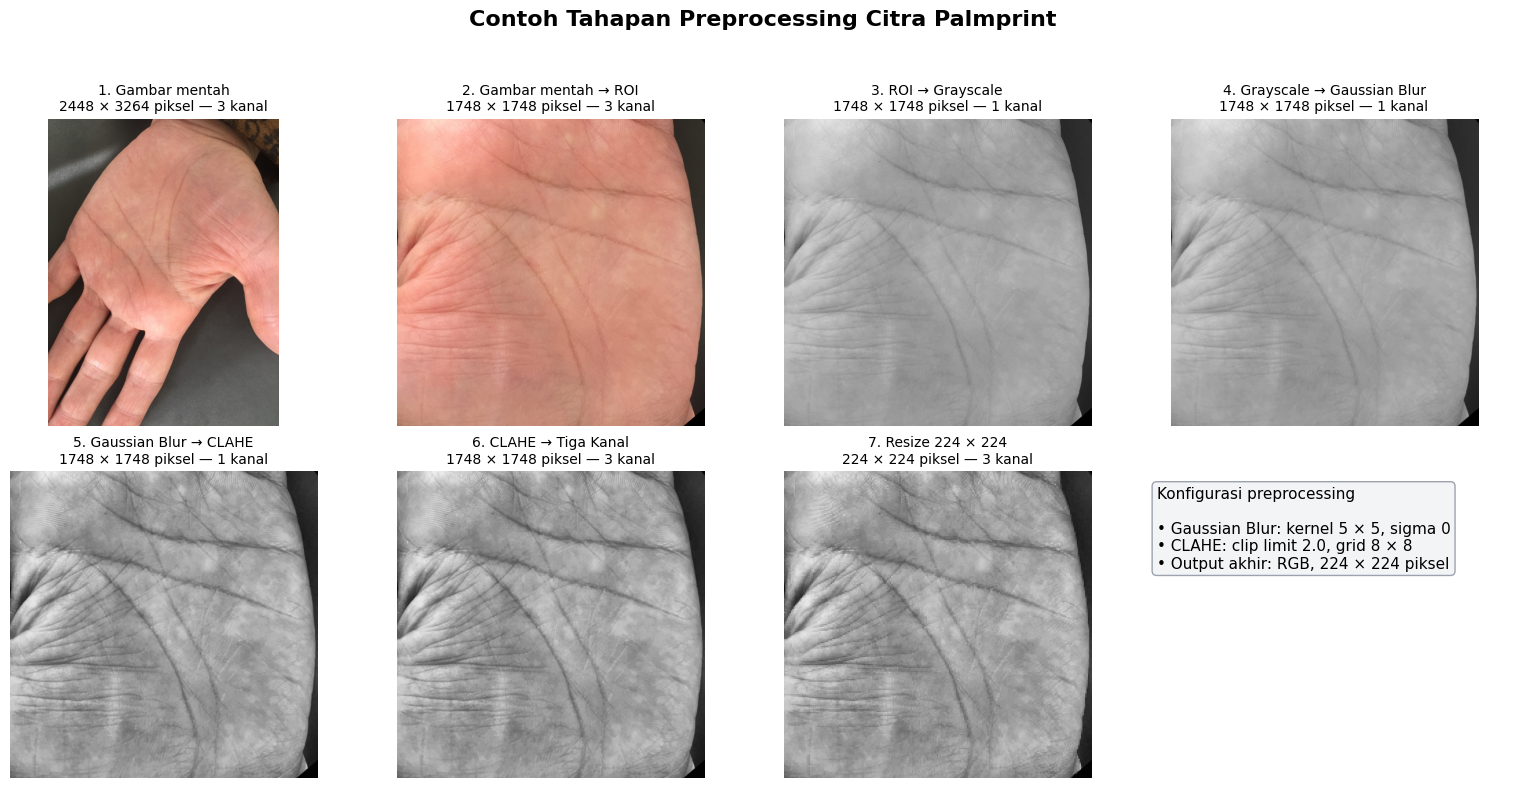

In [13]:
_ = DATASET_SPLIT_READY

def find_preprocessing_example():
    """Ambil satu gambar mentah yang berhasil melewati ekstraksi ROI."""
    for identity_name in sorted(os.listdir(DATASET_SPLIT_DIR)):
        identity_dir = os.path.join(DATASET_SPLIT_DIR, identity_name)
        if not os.path.isdir(identity_dir):
            continue

        for filename in sorted(os.listdir(identity_dir)):
            if not filename.lower().endswith(IMAGE_EXTENSIONS):
                continue

            image_path = os.path.join(identity_dir, filename)
            raw_image = cv2.imread(image_path)
            if raw_image is None:
                continue

            stage_result = extract_palm_roi(raw_image, return_stages=True)
            if stage_result is not None:
                _, stages = stage_result
                return image_path, stages

    raise RuntimeError(
        "Tidak ditemukan gambar yang berhasil dideteksi untuk contoh preprocessing."
    )

example_image_path, preprocessing_stages = find_preprocessing_example()

# Tampilkan tujuh tahap dalam satu gambar agar mudah dimasukkan ke laporan.
figure_stages, axes_stages = plt.subplots(2, 4, figsize=(16, 8))
axes_stages = axes_stages.ravel()

for stage_number, (stage_name, stage_image) in enumerate(
    preprocessing_stages.items(),
    start=1,
):
    current_axis = axes_stages[stage_number - 1]

    if stage_image.ndim == 2:
        current_axis.imshow(stage_image, cmap='gray', vmin=0, vmax=255)
        channel_text = '1 kanal'
    else:
        current_axis.imshow(stage_image)
        channel_text = f'{stage_image.shape[2]} kanal'

    image_height, image_width = stage_image.shape[:2]
    current_axis.set_title(
        f'{stage_number}. {stage_name}\n'
        f'{image_width} × {image_height} piksel — {channel_text}',
        fontsize=10,
    )
    current_axis.axis('off')

# Panel kedelapan dipakai untuk menjelaskan parameter utama preprocessing.
axes_stages[7].axis('off')
axes_stages[7].text(
    0.05,
    0.95,
    'Konfigurasi preprocessing\n\n'
    '• Gaussian Blur: kernel 5 × 5, sigma 0\n'
    '• CLAHE: clip limit 2.0, grid 8 × 8\n'
    '• Output akhir: RGB, 224 × 224 piksel',
    va='top',
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='#f3f4f6', edgecolor='#9ca3af'),
)

figure_stages.suptitle(
    'Contoh Tahapan Preprocessing Citra Palmprint',
    fontsize=16,
    fontweight='bold',
)
figure_stages.tight_layout(rect=[0, 0, 1, 0.95])

os.makedirs(ARTIFACT_DIR, exist_ok=True)
preprocessing_figure_path = os.path.join(
    ARTIFACT_DIR,
    'contoh_tahapan_preprocessing.png',
)
figure_stages.savefig(
    preprocessing_figure_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)

print('Contoh gambar:', example_image_path)
print('Visual preprocessing tersimpan:', preprocessing_figure_path)
plt.show()

### 5.2.2 Muat Data & Fungsi Embedding

#### [READ THIS] ngeload daftar user dari dataset_roi, fungsi baca gambar, rotasi ringan, dan fungsi embed_paths untuk menghasilkan embedding L2-normalized dengan TTA.

In [14]:
_ = ROI_READY

def identity_user(identity_id):
    """Kembalikan label user. Pada eksperimen ini satu folder ROI = satu orang = satu kelas."""
    return identity_id

def _make_imgs_of():
    """Setiap folder dataset_roi/<nama_orang> menjadi satu user."""
    _idx = {}
    _user_dirs = sorted(_d for _d in os.listdir(ROI_DIR) if os.path.isdir(os.path.join(ROI_DIR, _d)))
    for _user_dir_name in _user_dirs:
        _files = sorted(glob.glob(os.path.join(ROI_DIR, _user_dir_name, '*.png')))
        if len(_files) >= N_GALLERY + 1:
            _idx[identity_user(_user_dir_name)] = _files
    _ids = sorted(_idx)
    def imgs_of(label):
        return _idx[label]
    return _ids, imgs_of

ALL_IDS, imgs_of = _make_imgs_of()
print('Total user:', len(ALL_IDS))
if len(ALL_IDS) < N_TEST_ENROLLED + N_TEST_UNKNOWN + N_VAL_IDS + 1:
    print('PERINGATAN: jumlah user terlalu sedikit untuk skema cross-validation saat ini.')

def load_img(path):
    return cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), IMG_SIZE).astype(np.float32)

def rotate_image(img, deg):
    if deg == 0:
        return img
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2.0, h/2.0), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

def embed_paths(model, paths, tta=None, batch=64):
    """Ubah daftar citra menjadi embedding L2-normalized, dirata-rata lewat TTA rotasi."""
    if tta is None:
        tta = TTA_ROTATIONS
    if len(paths) == 0:
        return np.zeros((0, EMBED_DIM), np.float32)
    base = [load_img(p) for p in paths]
    accum = np.zeros((len(paths), EMBED_DIM), np.float32)
    for deg in tta:
        e = model.predict(np.stack([rotate_image(im, deg) for im in base]), verbose=0, batch_size=batch)
        accum += e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)
    accum /= len(tta)
    return (accum / (np.linalg.norm(accum, axis=1, keepdims=True) + 1e-9)).astype(np.float32)

Total user: 28


### 5.2.3 Kelas Pendukung — ArcFace & Callback

Hanya dua hal yang wajib berupa kelas terpisah: **ArcMarginProduct** (kepala ArcFace, dipakai saat latih saja) dan dua **callback** pelatihan (menaikkan margin bertahap; menghitung EER validasi untuk early stopping). Susunan layer dan augmentasi TIDAK ditaruh di sini — semuanya ditulis **inline** pada 5.2.4 agar alur pelatihan mudah dibaca.

#### [READ THIS] ArcFace sebagai head klasifikasi berbasis margin, EERValidation buat validasi tiap epoch, dan MarginWarmup buat menaikkan margin secara bertahap.

In [15]:
class ArcMarginProduct(layers.Layer):
    """Kepala ArcFace: menambah margin sudut pada logit kelas yang benar."""
    def __init__(self, n_classes, s=30.0, m=0.50, **kwargs):
        super().__init__(**kwargs)
        self.n_classes = n_classes
        self.s = s
        self._m_init = m
    def build(self, input_shape):
        self.W = self.add_weight(name='arc_W', shape=(int(input_shape[0][-1]), self.n_classes),
                                 initializer='glorot_uniform', trainable=True)
        self.m = tf.Variable(self._m_init, trainable=False, dtype=tf.float32, name='arc_m')
    def call(self, inputs):
        emb, labels = inputs
        W = tf.nn.l2_normalize(self.W, axis=0)
        cos_t = tf.clip_by_value(tf.matmul(emb, W), -1.0 + 1e-7, 1.0 - 1e-7)
        target = tf.cos(tf.acos(cos_t) + self.m)
        logits = cos_t * (1.0 - labels) + target * labels
        return tf.nn.softmax(logits * self.s)
    def get_config(self):
        config = super().get_config()
        config.update(
            n_classes=self.n_classes,
            s=self.s,
            m=self._m_init,
        )
        return config

class EERValidation(tf.keras.callbacks.Callback):
    """Hitung EER pada identitas validasi tiap akhir epoch (untuk early stopping)."""

    def __init__(self, embed_model, val_ids, n_gallery=N_GALLERY):
        super().__init__()
        self.embed_model = embed_model
        self.files_by_identity = {_person_id: imgs_of(_person_id) for _person_id in val_ids}
        self.n_gallery = n_gallery

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        templates_by_identity, validation_probes = ({}, [])
        for _person_id, _image_files in self.files_by_identity.items():
            _shuffled_files = list(_image_files)
            random.Random(SEED).shuffle(_shuffled_files)
            _gallery_files, _query_files = (_shuffled_files[:self.n_gallery], _shuffled_files[self.n_gallery:])
            if not _gallery_files or not _query_files:
                continue
            _template_embedding = embed_paths(self.embed_model, _gallery_files, tta=[0.0]).mean(0)
            templates_by_identity[_person_id] = _template_embedding / (np.linalg.norm(_template_embedding) + 1e-09)
            for _query_embedding in embed_paths(self.embed_model, _query_files, tta=[0.0]):
                validation_probes.append((_query_embedding, _person_id))
        if len(templates_by_identity) < 2 or not validation_probes:
            logs['val_eer'] = 1.0
            return
        identity_names = list(templates_by_identity)
        template_matrix = np.stack([templates_by_identity[_identity_name] for _identity_name in identity_names])
        genuine_scores, impostor_scores = ([], [])
        for _probe_embedding, _true_identity in validation_probes:
            _similarities = template_matrix @ _probe_embedding
            for _identity_index, _candidate_identity in enumerate(identity_names):
                (genuine_scores if _candidate_identity == _true_identity else impostor_scores).append(float(_similarities[_identity_index]))
        false_positive_rates, true_positive_rates, _thresholds = roc_curve(
            np.r_[np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))],
            np.r_[genuine_scores, impostor_scores],
        )
        false_negative_rates = 1 - true_positive_rates
        eer_index = int(np.nanargmin(np.abs(false_positive_rates - false_negative_rates)))
        logs['val_eer'] = float((false_positive_rates[eer_index] + false_negative_rates[eer_index]) / 2.0)

class MarginWarmup(tf.keras.callbacks.Callback):
    """Naikkan margin ArcFace dari 0 ke nilai akhir selama beberapa epoch pertama."""

    def __init__(self, layer, m_final, warmup):
        super().__init__()
        self.layer = layer
        self.m_final = m_final
        self.warmup_epochs = max(1, warmup)
        self.epoch_count = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.layer.m.assign(self.m_final * min(1.0, (self.epoch_count + 1) / self.warmup_epochs))
        self.epoch_count = self.epoch_count + 1

### 5.2.4 Rutin Pelatihan — Alur Inline (dataset → augmentasi → layer → compile → fit)

Satu fungsi `fit_model` memuat seluruh alur pelatihan berurutan, seperti membaca skrip dari atas ke bawah: **(1)** bangun dataset, **(2)** augmentasi inline, **(3)** susun layer model embedding + kepala ArcFace, **(4)** compile, **(5)** callback, **(6)** fit. Fungsi yang sama dipanggil ulang untuk demo (5.3.2), tiap fold cross-validation (5.3.3), dan model final (5.3.4).

#### [READ THIS] bagian training embedding model. prosesnya start dari dataset TensorFlow, augmentasi, EfficientNetB0 frozen, ArcFace, compile optimizer, callback, sampai fit.

In [16]:
def fit_model(train_ids, val_ids=None, verbose=0, return_history=False):
    """Latih model embedding satu tahap (backbone EfficientNetB0 dibekukan).

    Seluruh alur pelatihan ditulis INLINE di sini dan dibaca urut dari atas ke bawah:
    (1) dataset -> (2) augmentasi -> (3) layer model -> (4) compile -> (5) callback -> (6) fit.
    Kembalikan embedding_model (atau (embedding_model, history) bila return_history=True).
    """
    tf.keras.backend.clear_session()

    # -----------------------------
    # 1. Siapkan Dataset
    #    Satu identitas tangan dianggap sebagai satu kelas.
    #    Format data: ((citra, label one-hot), label one-hot).
    # -----------------------------
    class_names = list(train_ids)
    num_classes = len(class_names)
    class_to_index = {_name: _i for _i, _name in enumerate(class_names)}
    image_paths, class_labels = [], []
    for _name in class_names:
        for _image_file in imgs_of(_name):
            image_paths.append(_image_file)
            class_labels.append(class_to_index[_name])

    def _load_image_and_label(_path, _label):
        _image = tf.cast(tf.image.resize(tf.io.decode_png(tf.io.read_file(_path), channels=3), IMG_SIZE), tf.float32)
        return (_image, tf.one_hot(_label, num_classes))

    train_ds = tf.data.Dataset.from_tensor_slices((image_paths, class_labels)).shuffle(len(image_paths), seed=SEED)
    train_ds = train_ds.map(_load_image_and_label, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.map(lambda _image, _one_hot: ((_image, _one_hot), _one_hot), num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.batch(BATCH).prefetch(AUTOTUNE)

    # -----------------------------
    # 2. Data Augmentation
    #    Augmentasi hanya diterapkan selama proses pelatihan.
    # -----------------------------
    data_augmentation = tf.keras.Sequential([
        layers.RandomTranslation(0.06, 0.06, fill_mode='constant', fill_value=0.0),
        layers.RandomRotation(0.03, fill_mode='constant', fill_value=0.0),
        layers.RandomZoom(0.10, fill_mode='constant', fill_value=0.0),
        layers.RandomContrast(0.15),
    ], name='augment')

    # -----------------------------
    # 3. Bangun Model Embedding
    #    EfficientNetB0 -> Global Average Pooling -> Batch Normalization
    #    -> Dropout -> Dense 128 -> L2 normalization.
    #    Kepala ArcFace hanya digunakan saat training.
    # -----------------------------
    backbone = EfficientNetB0(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
    backbone.trainable = False  # satu tahap tanpa fine-tuning: backbone dibekukan

    emb_input = layers.Input(IMG_SIZE + (3,))
    x = backbone(emb_input)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(EMBED_DIM, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Lambda(lambda _t: tf.nn.l2_normalize(_t, axis=1), name='embedding')(x)
    embedding_model = models.Model(emb_input, x, name='embedding_model')

    image_in = layers.Input(IMG_SIZE + (3,), name='image')
    label_in = layers.Input((num_classes,), name='label')
    embedding_out = embedding_model(data_augmentation(image_in))
    arcface_out = ArcMarginProduct(num_classes, s=ARC_S, m=ARC_M_FINAL, name='arcface')([embedding_out, label_in])
    trainer = models.Model([image_in, label_in], arcface_out, name='trainer')

    # -----------------------------
    # 4. Compile Model
    #    Gunakan AdamW dan categorical cross-entropy dengan label smoothing.
    # -----------------------------
    try:
        optimizer = tf.keras.optimizers.AdamW(learning_rate=LR_TRAIN, weight_decay=WEIGHT_DECAY)
    except Exception:
        optimizer = tf.keras.optimizers.Adam(learning_rate=LR_TRAIN)
    trainer.compile(optimizer, loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH), metrics=['accuracy'])

    # -----------------------------
    # 5. Callback
    #    Margin ArcFace dinaikkan secara bertahap.
    #    Early stopping menggunakan EER validasi.
    # -----------------------------
    training_callbacks = [MarginWarmup(trainer.get_layer('arcface'), ARC_M_FINAL, ARC_M_WARMUP_EPOCHS)]
    if val_ids:
        training_callbacks.append(EERValidation(embedding_model, val_ids))
        training_callbacks.append(tf.keras.callbacks.EarlyStopping('val_eer', mode='min', patience=ES_PATIENCE, restore_best_weights=True))

    # -----------------------------
    # 6. Latih Model
    # -----------------------------
    train_history = trainer.fit(train_ds, epochs=TRAIN_EPOCHS, callbacks=training_callbacks, verbose=verbose)

    if return_history:
        return embedding_model, train_history
    return embedding_model

### 5.2.5 Identitas Evaluasi

Seluruh user masuk ke proses cross-validation. Tidak ada data hold-out yang disisihkan di luar evaluasi; setiap user berpotensi menjadi train, validation, enrolled, atau unknown pada fold yang berbeda.

#### [READ THIS] cell ini menetapkan semua user ROI sebagai kandidat evaluasi. Tidak ada hold-out tetap, karena pembagian user diputar di setiap fold cross-validation.

In [17]:
_ = ROI_READY

EVAL_IDS = ALL_IDS

print("Seluruh user masuk ke proses cross-validation:", len(EVAL_IDS))
EVAL_IDS

Seluruh user masuk ke proses cross-validation: 28


['Abi Al Qhafari',
 'Aldin Pramudya',
 'Cahaya Indrasmara',
 'Dewa Anggoro Mulianto',
 'Dhana Reyhan',
 'Fajar Cita Wibowo',
 'Fauzan Habibi',
 'Ikrar Budi Dharma',
 'Ken Arya Rizkyka',
 'MUHAMMAD HAIDAR SHAHAB',
 'Marthalita Dwi',
 'Muhamad Enrinal Zulhimar',
 'Muhammad Ariq Pratama',
 'Muhammad Gading',
 'Muhammad Maul',
 'Muhammad Ridho Habibie',
 'Muhammad Tegar',
 'Naufalsyah Falah Muhammad',
 'Pahlevi Aulia',
 'Ramadhani Wijaya',
 'Razoub Ramadhan',
 'Riski Jaya',
 'Rizki Evan',
 'Roziq Mahbubi',
 'Sadam Firdaus Ubaidilah',
 'Taufik Mulyawan',
 'Trio Adhi Pamungkas',
 'Wildan ihza mahbubi']

---

## 5.3 Pengujian & Evaluasi

Bagian ini mendefinisikan protokol evaluasi (enroll/probe/unknown), mendemonstrasikan pelatihan satu model, menjalankan evaluasi menyeluruh cross-validation, lalu melatih & mengekspor model final.

### 5.3.1 Fungsi Evaluasi (enroll / probe / unknown)

#### [READ THIS] eval function: pembagian fold per user, validasi split, EER, Rank-1, Open-set False Accept, ringkasan skor, dan evaluasi enrolled vs unknown.

In [18]:
def make_folds(all_ids, fold_count, enrolled_count, unknown_count, validation_count, seed=SEED):
    """Buat fold evaluasi berbasis user.

    Label kelas = satu orang. Pada setiap fold, user dibagi menjadi empat kelompok
    yang saling lepas: train, validation, enrolled, dan unknown. Seluruh user tetap
    masuk proses evaluasi karena fold diulang dengan seed berbeda.
    """
    folds = []
    user_ids = sorted(all_ids)
    required_users = enrolled_count + unknown_count + validation_count + 1
    if len(user_ids) < required_users:
        raise ValueError(
            f"Jumlah user tidak cukup: butuh minimal {required_users}, tersedia {len(user_ids)}."
        )
    for _fold_index in range(fold_count):
        _shuffled_users = list(user_ids)
        random.Random(seed + _fold_index).shuffle(_shuffled_users)
        _enrolled_end = enrolled_count
        _unknown_end = enrolled_count + unknown_count
        _validation_end = enrolled_count + unknown_count + validation_count
        folds.append(dict(
            enrolled=sorted(_shuffled_users[:_enrolled_end]),
            unknown=sorted(_shuffled_users[_enrolled_end:_unknown_end]),
            val=sorted(_shuffled_users[_unknown_end:_validation_end]),
            train=sorted(_shuffled_users[_validation_end:]),
        ))
    return folds

def validate_fold_disjoint(fold):
    """Pastikan user tidak muncul di lebih dari satu split pada fold yang sama."""
    split_sets = {
        'enrolled': set(fold['enrolled']),
        'unknown': set(fold['unknown']),
        'val': set(fold['val']),
        'train': set(fold['train']),
    }
    split_names = list(split_sets)
    overlaps = []
    for _left_index, _left_name in enumerate(split_names):
        for _right_name in split_names[_left_index + 1:]:
            overlap = split_sets[_left_name] & split_sets[_right_name]
            if overlap:
                overlaps.append((_left_name, _right_name, sorted(overlap)))
    if overlaps:
        raise ValueError(f"Kebocoran split terdeteksi: {overlaps}")
    return True

def compute_eer(genuine_scores, impostor_scores):
    """Dari skor genuine & impostor: kembalikan (AUC, EER, fpr, tpr, thr)."""
    false_positive_rates, true_positive_rates, thresholds = roc_curve(
        np.r_[np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))],
        np.r_[genuine_scores, impostor_scores],
    )
    false_negative_rates = 1 - true_positive_rates
    eer_index = int(np.nanargmin(np.abs(false_positive_rates - false_negative_rates)))
    return (
        float(auc(false_positive_rates, true_positive_rates)),
        float((false_positive_rates[eer_index] + false_negative_rates[eer_index]) / 2.0),
        false_positive_rates,
        true_positive_rates,
        thresholds,
    )

def compute_rank1_accuracy(probe_best_matches):
    """Pure Rank-1 Accuracy: benar jika skor tertinggi berasal dari user yang benar, tanpa threshold."""
    if not probe_best_matches:
        return 0.0
    return float(np.mean([is_correct for _score, is_correct in probe_best_matches]))

def open_set_false_accept_rate(unknown_max_scores, threshold):
    """Open-set False Accept: proporsi probe unknown yang diterima oleh sistem pada threshold tertentu."""
    scores = np.asarray(unknown_max_scores, dtype=np.float32)
    if scores.size == 0:
        return 0.0
    return float(np.mean(scores >= threshold))

def threshold_at_open_set_fa(unknown_max_scores, target_open_set_fa):
    """Ambil threshold paling longgar yang menjaga Open-set False Accept <= target."""
    scores = np.asarray(unknown_max_scores, dtype=np.float32)
    if scores.size == 0:
        return float('inf')
    unique_scores = np.sort(np.unique(scores))[::-1]
    candidates = np.r_[np.nextafter(float(np.max(unique_scores)), float('inf')), unique_scores]
    valid_thresholds = [threshold for threshold in candidates if open_set_false_accept_rate(scores, threshold) <= target_open_set_fa]
    return float(valid_thresholds[-1] if valid_thresholds else candidates[0])

def score_distribution_summary(scores):
    """Ringkasan skor untuk menggantikan CI bootstrap: pusat, sebaran, dan rentang persentil."""
    scores = np.asarray(scores, dtype=np.float32)
    if scores.size == 0:
        return dict(n=0, mean=None, std=None, min=None, p05=None, median=None, p95=None, max=None)
    return dict(
        n=int(scores.size),
        mean=float(np.mean(scores)),
        std=float(np.std(scores)),
        min=float(np.min(scores)),
        p05=float(np.percentile(scores, 5)),
        median=float(np.percentile(scores, 50)),
        p95=float(np.percentile(scores, 95)),
        max=float(np.max(scores)),
    )

def evaluate_fold(embed_model, enrolled_ids, unknown_ids):
    """Bentuk template untuk tiap user terdaftar, lalu skor probe enrolled dan unknown."""
    templates_by_user, enrolled_probes = ({}, [])
    for _user_id in enrolled_ids:
        _user_files = list(imgs_of(_user_id))
        random.Random(SEED).shuffle(_user_files)
        gallery_files, query_files = (_user_files[:N_GALLERY], _user_files[N_GALLERY:])
        if gallery_files:
            template_embedding = embed_paths(embed_model, gallery_files).mean(0)
            templates_by_user[_user_id] = template_embedding / (np.linalg.norm(template_embedding) + 1e-09)
        for probe_embedding in embed_paths(embed_model, query_files):
            enrolled_probes.append((probe_embedding, _user_id))
    enrolled_user_names = list(templates_by_user)
    template_matrix = np.stack([templates_by_user[_user_id] for _user_id in enrolled_user_names])

    genuine_scores, closed_set_impostor_scores, best_probe_matches = ([], [], [])
    for probe_embedding, true_user in enrolled_probes:
        similarities = template_matrix @ probe_embedding
        for _user_index, candidate_user in enumerate(enrolled_user_names):
            (genuine_scores if candidate_user == true_user else closed_set_impostor_scores).append(float(similarities[_user_index]))
        predicted_index = int(np.argmax(similarities))
        best_probe_matches.append((float(similarities[predicted_index]), enrolled_user_names[predicted_index] == true_user))

    unknown_pair_scores, unknown_max_scores = ([], [])
    for unknown_user in unknown_ids:
        for unknown_embedding in embed_paths(embed_model, imgs_of(unknown_user)):
            unknown_scores = template_matrix @ unknown_embedding
            unknown_pair_scores = unknown_pair_scores + [float(score) for score in unknown_scores]
            unknown_max_scores.append(float(np.max(unknown_scores)))
    return dict(
        gen=genuine_scores,
        imp=closed_set_impostor_scores + unknown_pair_scores,
        closed_imp=closed_set_impostor_scores,
        unknown_pair=unknown_pair_scores,
        probe_best=best_probe_matches,
        unk_max=unknown_max_scores,
    )

### 5.3.2 Demonstrasi Pelatihan Satu Model

#### [READ THIS] proses ngetrain model demo memakai satu fold. Tujuannya buat melihat proses training lengkap sebelum menjalankan cross-validation yang lebih lama.

In [19]:
mo.stop(
    "EVAL_IDS" not in globals(),
    mo.md("""
    **EVAL_IDS belum tersedia.**

    Jalankan cell Azure dengan environment variable `AZ_KEY` yang valid agar dataset diunduh,
    ROI diproses, dan daftar user evaluasi terbentuk sebelum demo pelatihan dijalankan.
    """),
)

# Ambil satu pembagian representatif untuk mendemokan proses belajar
demo = make_folds(EVAL_IDS, 1, N_TEST_ENROLLED, N_TEST_UNKNOWN, N_VAL_IDS)[0]
validate_fold_disjoint(demo)
print('Jumlah user -> train: %d | val: %d | enrolled: %d | unknown: %d' % (
    len(demo['train']), len(demo['val']), len(demo['enrolled']), len(demo['unknown'])))

# verbose=1 -> progres tiap epoch ditampilkan (loss, accuracy, val_eer)
demo_model, demo_history = fit_model(demo['train'], demo['val'], verbose=1, return_history=True)

Jumlah user -> train: 18 | val: 4 | enrolled: 3 | unknown: 3

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 417ms/step - accuracy: 0.4526 - loss: 2.8098 - val_eer: 0.2847
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - accuracy: 0.7303 - loss: 1.3090 - val_eer: 0.2701
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.8170 - loss: 1.0226 - val_eer: 0.2689
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.7913 - loss: 1.1219 - val_eer: 0.2798
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.7961 - loss: 1.1643 - val_eer: 0.2530
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step - accuracy: 0.7721 - loss: 1.2646 - val_eer: 0.2652
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.7753 - loss: 1.1988 - val_eer: 0.2409
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.7640 - loss: 1.3764 - val_eer: 0.2470
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.7865 - loss: 1.1952 - val_eer:

#### [READ THIS] visualisasi train loss dan EER dari model demo. Fungsinya mempermudah pengamatan kinerja model, apakah training stabil atau mulai overfit.

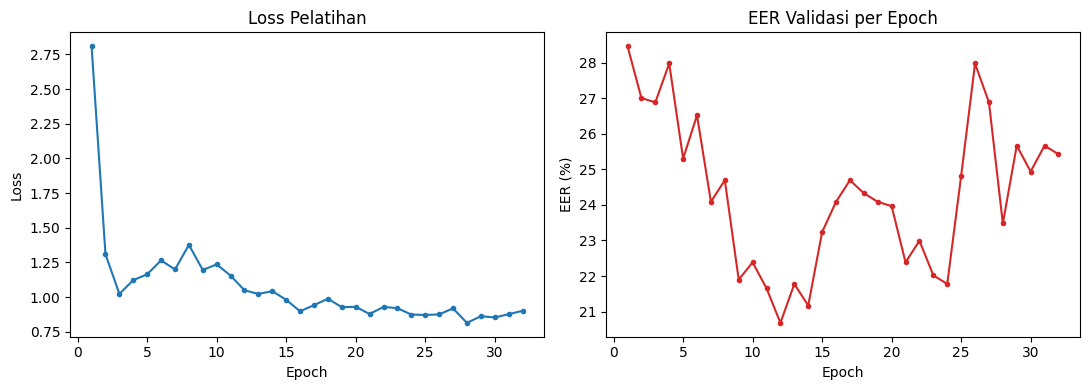

In [20]:
# Kurva belajar untuk pelatihan satu tahap tanpa fine-tuning
loss_curve = list(demo_history.history['loss'])
eer_curve = list(demo_history.history.get('val_eer', []))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, len(loss_curve) + 1), loss_curve, marker='o', ms=3)
ax[0].set_title('Loss Pelatihan')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
if eer_curve:
    ax[1].plot(range(1, len(eer_curve) + 1), [e * 100 for e in eer_curve], marker='o', ms=3, c='tab:red')
    ax[1].set_title('EER Validasi per Epoch')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('EER (%)')
plt.tight_layout()
plt.show()

#### [READ THIS] cell ini menguji model demo pada user enrolled dan unknown dari fold yang sama, lalu mencetak EER, AUC, Pure Rank-1 Accuracy, dan Open-set False Accept.

In [21]:
# Uji model demo pada user terdaftar + user asing dari fold yang sama
demo_evaluation = evaluate_fold(demo_model, demo['enrolled'], demo['unknown'])
demo_auc, demo_eer, _, _, _ = compute_eer(np.array(demo_evaluation['gen']), np.array(demo_evaluation['imp']))
demo_rank1 = compute_rank1_accuracy(demo_evaluation['probe_best'])
demo_threshold = threshold_at_open_set_fa(demo_evaluation['unk_max'], max(TARGET_OPEN_SET_FA))
demo_open_set_fa = open_set_false_accept_rate(demo_evaluation['unk_max'], demo_threshold)
print('Model demo -> EER = %.2f%% | AUC = %.4f | Pure Rank-1 Accuracy = %.2f%% | Open-set False Accept = %.2f%%' % (
    demo_eer * 100,
    demo_auc,
    demo_rank1 * 100,
    demo_open_set_fa * 100,
))

Model demo -> EER = 2.07% | AUC = 0.9992 | Pure Rank-1 Accuracy = 100.00% | Open-set False Accept = 0.83%


### 5.3.3 Evaluasi Menyeluruh — Cross-Validation N Fold

#### [READ THIS] cell ini menjalankan evaluasi 10 fold. Setiap fold melatih model baru, mengukur EER dan Rank-1, trus menggabungkan skor genuine, impostor, dan unknown untuk final result.

In [22]:
mo.stop(
    "EVAL_IDS" not in globals(),
    mo.md("""
    **EVAL_IDS belum tersedia.**

    Jalankan cell Azure dengan environment variable `AZ_KEY` yang valid agar daftar user evaluasi tersedia
    sebelum cross-validation dijalankan.
    """),
)

folds = make_folds(EVAL_IDS, N_FOLDS, N_TEST_ENROLLED, N_TEST_UNKNOWN, N_VAL_IDS)
pooled_genuine_scores, pooled_impostor_scores = ([], [])
per_fold_eer, per_fold_rank1, all_probe_best_matches, all_unknown_max_scores, tested_users = ([], [], [], [], set())
for fold_index, fold in enumerate(folds):
    validate_fold_disjoint(fold)
    embed_model = fit_model(fold['train'], fold['val'])
    fold_evaluation = evaluate_fold(embed_model, fold['enrolled'], fold['unknown'])
    fold_genuine_scores = np.array(fold_evaluation['gen'])
    fold_impostor_scores = np.array(fold_evaluation['imp'])
    _, fold_eer, _, _, _ = compute_eer(fold_genuine_scores, fold_impostor_scores)
    fold_rank1 = compute_rank1_accuracy(fold_evaluation['probe_best'])
    per_fold_eer.append(fold_eer)
    per_fold_rank1.append(fold_rank1)
    pooled_genuine_scores.append(fold_genuine_scores)
    pooled_impostor_scores.append(fold_impostor_scores)
    all_probe_best_matches = all_probe_best_matches + fold_evaluation['probe_best']
    all_unknown_max_scores = all_unknown_max_scores + fold_evaluation['unk_max']
    tested_users = tested_users | (set(fold['enrolled']) | set(fold['unknown']))
    print(
        'Fold', fold_index + 1, '/', N_FOLDS,
        '| train_user=', len(fold['train']),
        '| EER=%.2f%%' % (fold_eer * 100),
        '| Pure Rank-1=%.2f%%' % (fold_rank1 * 100),
    )
pooled_genuine_scores = np.concatenate(pooled_genuine_scores)
pooled_impostor_scores = np.concatenate(pooled_impostor_scores)
AUC, EER, fpr, tpr, thr = compute_eer(pooled_genuine_scores, pooled_impostor_scores)
per_fold_eer_array = np.array(per_fold_eer)
per_fold_rank1_array = np.array(per_fold_rank1)
rank1_accuracy = compute_rank1_accuracy(all_probe_best_matches)
genuine_summary = score_distribution_summary(pooled_genuine_scores)
impostor_summary = score_distribution_summary(pooled_impostor_scores)
unknown_max_summary = score_distribution_summary(all_unknown_max_scores)
print('\n==== HASIL CROSS-VALIDATION PER USER ===')
print('Fold=%d | user teruji=%d/%d' % (
    N_FOLDS,
    len(tested_users),
    len(EVAL_IDS),
))
print('EER per-fold: mean=%.2f%% | min=%.2f%% max=%.2f%%' % (
    per_fold_eer_array.mean() * 100,
    per_fold_eer_array.min() * 100,
    per_fold_eer_array.max() * 100,
))
print('Pure Rank-1 Accuracy: %.2f%% | per-fold mean=%.2f%%' % (
    rank1_accuracy * 100,
    per_fold_rank1_array.mean() * 100,
))
print('EER pooled: %.2f%% | AUC=%.4f' % (EER * 100, AUC))
print('Ringkasan genuine score:', json.dumps(genuine_summary, indent=2))
print('Ringkasan impostor score:', json.dumps(impostor_summary, indent=2))
print('Ringkasan unknown max score:', json.dumps(unknown_max_summary, indent=2))

Fold 1 / 10 | train_user= 18 | EER=1.98% | Pure Rank-1=100.00%
Fold 2 / 10 | train_user= 18 | EER=7.34% | Pure Rank-1=100.00%
Fold 3 / 10 | train_user= 18 | EER=1.56% | Pure Rank-1=99.07%
Fold 4 / 10 | train_user= 18 | EER=9.82% | Pure Rank-1=100.00%
Fold 5 / 10 | train_user= 18 | EER=9.10% | Pure Rank-1=96.63%
Fold 6 / 10 | train_user= 18 | EER=18.79% | Pure Rank-1=90.10%
Fold 7 / 10 | train_user= 18 | EER=6.72% | Pure Rank-1=97.83%
Fold 8 / 10 | train_user= 18 | EER=2.06% | Pure Rank-1=100.00%
Fold 9 / 10 | train_user= 18 | EER=14.45% | Pure Rank-1=85.85%
Fold 10 / 10 | train_user= 18 | EER=0.98% | Pure Rank-1=99.07%

==== HASIL CROSS-VALIDATION PER USER ===
Fold=10 | user teruji=26/28
EER per-fold: mean=7.28% | min=0.98% max=18.79%
Pure Rank-1 Accuracy: 96.84% | per-fold mean=96.86%
EER pooled: 8.59% | AUC=0.9681
Ringkasan genuine score: {
  "n": 1013,
  "mean": 0.8175138235092163,
  "std": 0.1678406298160553,
  "min": -0.25808316469192505,
  "p05": 0.454964280128479,
  "median": 0.

#### [READ THIS] proses mencari threshold operasi based on target Open-set False Accept, ngitung trade-off FRR, visualisasi hasil evaluasi 2x2 untuk laporan.

Threshold operasi berbasis Open-set False Accept (skor unknown max):
  Open-set FA<=0.1% -> threshold=0.8131 | Closed-set accept=66.63% | FRR=33.37% | Observed Open-set FA=0.09%
  Open-set FA<=1.0% -> threshold=0.7737 | Closed-set accept=75.72% | FRR=24.28% | Observed Open-set FA=0.94%
Visual laporan tersimpan: artifacts/evaluasi_cross_validation_10x.png


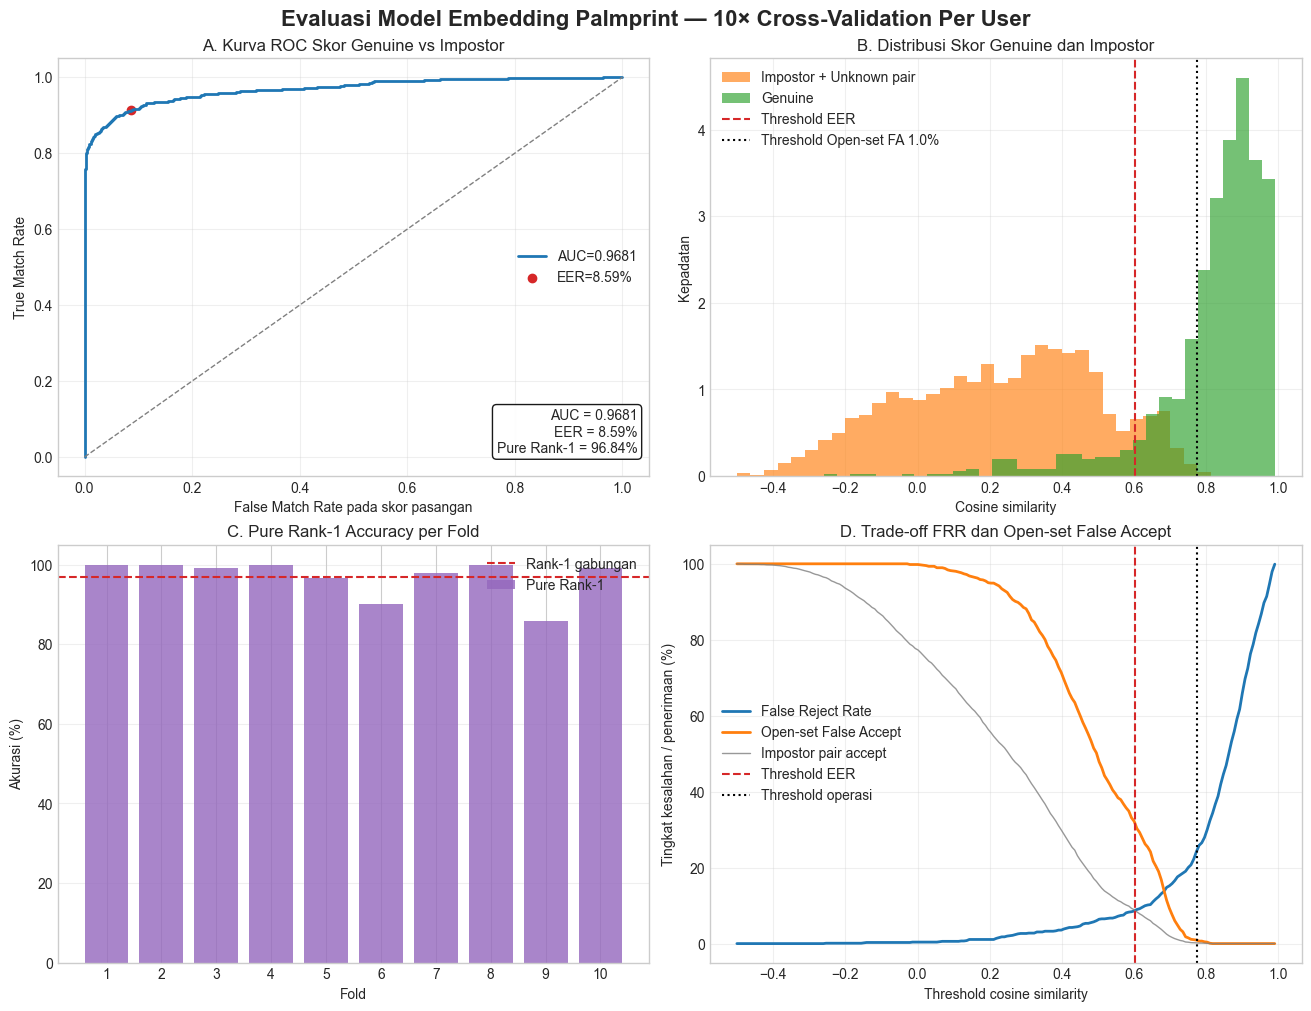

In [23]:
print('Threshold operasi berbasis Open-set False Accept (skor unknown max):')
open_set_operating_points = []
for target_open_set_fa in TARGET_OPEN_SET_FA:
    operating_threshold = threshold_at_open_set_fa(all_unknown_max_scores, target_open_set_fa)
    closed_set_accept_rate = np.mean([score >= operating_threshold for score, _ in all_probe_best_matches])
    false_reject_rate = np.mean([score < operating_threshold for score, _ in all_probe_best_matches])
    observed_open_set_fa = open_set_false_accept_rate(all_unknown_max_scores, operating_threshold)
    open_set_operating_points.append(dict(
        target_open_set_fa=target_open_set_fa,
        threshold=operating_threshold,
        closed_set_accept_rate=float(closed_set_accept_rate),
        false_reject_rate=float(false_reject_rate),
        observed_open_set_fa=observed_open_set_fa,
    ))
    print('  Open-set FA<=%.1f%% -> threshold=%.4f | Closed-set accept=%.2f%% | FRR=%.2f%% | Observed Open-set FA=%.2f%%' % (
        target_open_set_fa * 100,
        operating_threshold,
        closed_set_accept_rate * 100,
        false_reject_rate * 100,
        observed_open_set_fa * 100,
    ))

eer_threshold_index = int(np.nanargmin(np.abs(fpr - (1 - tpr))))
eer_threshold = float(thr[eer_threshold_index])
operating_threshold_report = open_set_operating_points[-1]['threshold']
threshold_grid = np.linspace(
    min(float(np.min(pooled_impostor_scores)), float(np.min(pooled_genuine_scores))),
    max(float(np.max(pooled_impostor_scores)), float(np.max(pooled_genuine_scores))),
    200,
)
impostor_accept_curve = np.array([np.mean(pooled_impostor_scores >= _threshold) for _threshold in threshold_grid])
genuine_reject_curve = np.array([np.mean(pooled_genuine_scores < _threshold) for _threshold in threshold_grid])
unknown_accept_curve = np.array([open_set_false_accept_rate(all_unknown_max_scores, _threshold) for _threshold in threshold_grid])

# Visual utama siap laporan: label Indonesia, anotasi metrik, dan ekspor PNG 300 dpi.
plt.style.use('seaborn-v0_8-whitegrid')
fig_eval, ax_eval = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
fig_eval.suptitle(
    'Evaluasi Model Embedding Palmprint — %d× Cross-Validation Per User' % N_FOLDS,
    fontsize=16,
    fontweight='bold',
)
ax_eval[0, 0].plot(fpr, tpr, label='AUC=%.4f' % AUC, color='tab:blue', linewidth=2)
ax_eval[0, 0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax_eval[0, 0].scatter([fpr[eer_threshold_index]], [tpr[eer_threshold_index]], color='tab:red', label='EER=%.2f%%' % (EER * 100))
ax_eval[0, 0].set_xlabel('False Match Rate pada skor pasangan')
ax_eval[0, 0].set_ylabel('True Match Rate')
ax_eval[0, 0].set_title('A. Kurva ROC Skor Genuine vs Impostor')
ax_eval[0, 0].text(
    0.98, 0.05,
    'AUC = %.4f\nEER = %.2f%%\nPure Rank-1 = %.2f%%' % (AUC, EER * 100, rank1_accuracy * 100),
    transform=ax_eval[0, 0].transAxes,
    ha='right', va='bottom',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
)
ax_eval[0, 0].legend()
ax_eval[0, 0].grid(alpha=0.3)

ax_eval[0, 1].hist(pooled_impostor_scores, bins=35, alpha=0.65, label='Impostor + Unknown pair', color='tab:orange', density=True)
ax_eval[0, 1].hist(pooled_genuine_scores, bins=35, alpha=0.65, label='Genuine', color='tab:green', density=True)
ax_eval[0, 1].axvline(eer_threshold, color='tab:red', linestyle='--', label='Threshold EER')
ax_eval[0, 1].axvline(operating_threshold_report, color='black', linestyle=':', label='Threshold Open-set FA %.1f%%' % (max(TARGET_OPEN_SET_FA) * 100))
ax_eval[0, 1].set_xlabel('Cosine similarity')
ax_eval[0, 1].set_ylabel('Kepadatan')
ax_eval[0, 1].set_title('B. Distribusi Skor Genuine dan Impostor')
ax_eval[0, 1].legend()
ax_eval[0, 1].grid(alpha=0.3)

ax_eval[1, 0].bar(range(1, len(per_fold_rank1_array) + 1), per_fold_rank1_array * 100, color='tab:purple', alpha=0.8, label='Pure Rank-1')
ax_eval[1, 0].axhline(rank1_accuracy * 100, color='tab:red', linestyle='--', label='Rank-1 gabungan')
ax_eval[1, 0].set_xlabel('Fold')
ax_eval[1, 0].set_ylabel('Akurasi (%)')
ax_eval[1, 0].set_title('C. Pure Rank-1 Accuracy per Fold')
ax_eval[1, 0].set_xticks(range(1, len(per_fold_rank1_array) + 1))
ax_eval[1, 0].legend()
ax_eval[1, 0].grid(axis='y', alpha=0.3)

ax_eval[1, 1].plot(threshold_grid, genuine_reject_curve * 100, label='False Reject Rate', color='tab:blue', linewidth=2)
ax_eval[1, 1].plot(threshold_grid, unknown_accept_curve * 100, label='Open-set False Accept', color='tab:orange', linewidth=2)
ax_eval[1, 1].plot(threshold_grid, impostor_accept_curve * 100, label='Impostor pair accept', color='tab:gray', linewidth=1, alpha=0.8)
ax_eval[1, 1].axvline(eer_threshold, color='tab:red', linestyle='--', label='Threshold EER')
ax_eval[1, 1].axvline(operating_threshold_report, color='black', linestyle=':', label='Threshold operasi')
ax_eval[1, 1].set_xlabel('Threshold cosine similarity')
ax_eval[1, 1].set_ylabel('Tingkat kesalahan / penerimaan (%)')
ax_eval[1, 1].set_title('D. Trade-off FRR dan Open-set False Accept')
ax_eval[1, 1].legend()
ax_eval[1, 1].grid(alpha=0.3)

figure_png = '%s/evaluasi_cross_validation_10x.png' % ARTIFACT_DIR
fig_eval.savefig(figure_png, dpi=300, bbox_inches='tight', facecolor='white')
print('Visual laporan tersimpan:', figure_png)
plt.show()

### 5.3.4 Latih Model Final & Ekspor

#### [READ THIS] final model training, menyimpan model Keras dan TFLite, menulis metadata evaluasi ke JSON, lalu upload artifacts ke Azure.

In [24]:
final_fold = make_folds(EVAL_IDS, 1, N_TEST_ENROLLED, N_TEST_UNKNOWN, N_VAL_IDS, seed=SEED + 10_000)[0]
validate_fold_disjoint(final_fold)
embedding_model = fit_model(final_fold['train'], val_ids=final_fold['val'])
OPERATING_OPEN_SET_FA = max(TARGET_OPEN_SET_FA)
OPERATING_THRESHOLD = threshold_at_open_set_fa(all_unknown_max_scores, OPERATING_OPEN_SET_FA)
print('OPERATING_THRESHOLD =', round(OPERATING_THRESHOLD, 4))
print('Final training -> train_user=%d | val_user=%d' % (
    len(final_fold['train']),
    len(final_fold['val']),
))

os.makedirs(ARTIFACT_DIR, exist_ok=True)
embedding_model.save(os.path.join(ARTIFACT_DIR, 'palm_embedding.keras'))
conv = tf.lite.TFLiteConverter.from_keras_model(embedding_model)
# float32 = akurasi terbaik. Untuk fp16 (model lebih kecil), buka 2 baris ini:
# conv.optimizations = [tf.lite.Optimize.DEFAULT]
# conv.target_spec.supported_types = [tf.float16]
open(os.path.join(ARTIFACT_DIR, 'palm_embedding.tflite'), 'wb').write(conv.convert())

meta = {
    'embedding_dim': EMBED_DIM,
    'img_size': list(IMG_SIZE),
    'input_range': '0-255 float32',
    'similarity': 'cosine L2-norm',
    'operating_threshold': OPERATING_THRESHOLD,
    'operating_open_set_false_accept_target': OPERATING_OPEN_SET_FA,
    'cross_validation_iterations': N_FOLDS,
    'cv_eer_pooled': EER,
    'cv_auc': AUC,
    'cv_pure_rank1_accuracy': rank1_accuracy,
    'score_summary': {
        'genuine': genuine_summary,
        'impostor': impostor_summary,
        'unknown_max': unknown_max_summary,
    },
    'open_set_operating_points': open_set_operating_points,
    'tta_rotations': TTA_ROTATIONS,
    'identity_definition': 'Label kelas = satu orang; foto tangan kiri dan kanan milik orang yang sama digabung sebagai user yang sama.',
    'split_policy': 'Tidak ada hold-out tetap; seluruh user masuk ke skema cross-validation dan diputar sebagai train, validation, enrolled, atau unknown.',
    'final_train_users': final_fold['train'],
    'final_val_users': final_fold['val'],
    'preprocessing': 'MediaPipe Hand Landmarker ROI -> grayscale -> GaussianBlur(5x5) -> CLAHE(2.0,8x8) -> GRAY2RGB -> resize 224',
}
json.dump(meta, open(os.path.join(ARTIFACT_DIR, 'model_metadata.json'), 'w'), indent=2)
fs.put(f"{ARTIFACT_DIR}/", f"{CONTAINER}/{ARTIFACT_DIR}/", recursive=True)
print(json.dumps(meta, indent=2))

OPERATING_THRESHOLD = 0.7737
Final training -> train_user=18 | val_user=4
INFO:tensorflow:Assets written to: C:\Users\LOQ\AppData\Local\Temp\tmpvj_cvkef\assets


INFO:tensorflow:Assets written to: C:\Users\LOQ\AppData\Local\Temp\tmpvj_cvkef\assets


Saved artifact at 'C:\Users\LOQ\AppData\Local\Temp\tmpvj_cvkef'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 128), dtype=tf.float32, name=None)
Captures:
  1629042642960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1629042643136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1631031842896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1631042407584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629202648752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1631031267520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1631042416384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1631042416912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1631044036288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1631044037168: TensorSpec(shape=(), dtype=tf.resour